--- Top 10 Headquarters ---
1. Mumbai,Maharashtra + 276 more
2. Dublin + 139 more
3. Teaneck. New Jersey. + 109 more
4. Mumbai,Maharashtra + 1159 more
5. Bangalore/Bengaluru,Karnataka + 235 more
6. Mumbai,Maharashtra + 1390 more
7. Bengaluru/Bangalore,Karnataka + 132 more
8. Paris + 81 more
9. Pune,Maharashtra + 221 more
10. New York,New York + 76 more
Saved bar_chart_rating.png


Saved line_chart_employees.png
Saved pie_chart_years.png


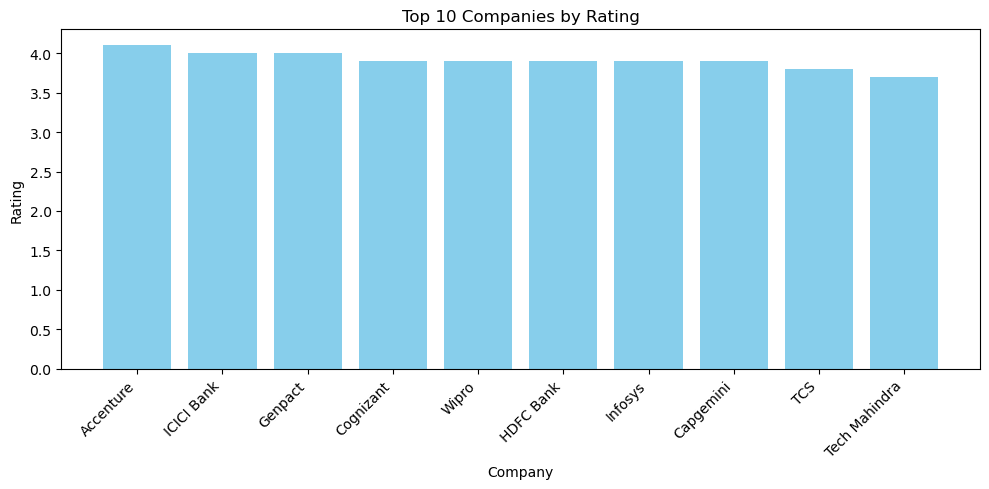

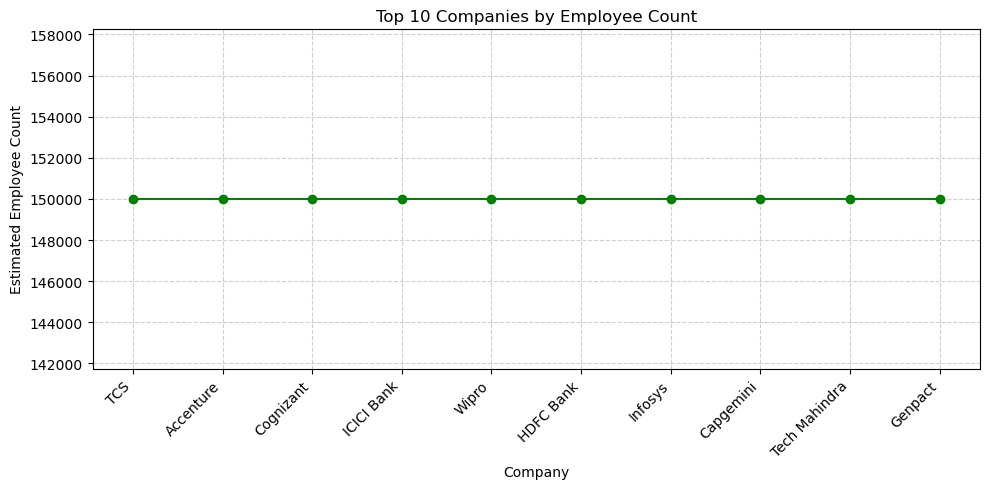

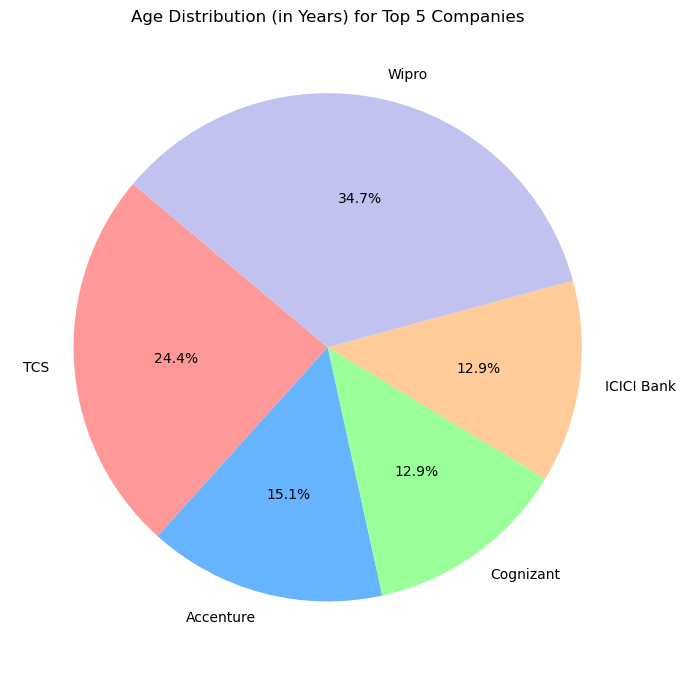

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px  # This fixes the 'px' error!

# --- Load Data ---
# Make sure your VS Code terminal is opened in the same folder as this CSV file
df = pd.read_csv('company_dataset.csv')

# --- Data Cleaning ---
df['review_numeric'] = df['review_count'].str.extract(r'\(([\d\.]+)[kK]?\s*Reviews\)')[0].astype(float) * 1000
df['years_numeric'] = df['years'].str.extract(r'(\d+)').astype(float)

def map_employees(x):
    if pd.isna(x): return 0
    if '1 Lakh+' in x: return 150000
    elif '50k-1 Lakh' in x: return 75000
    elif '10k-50k' in x: return 30000
    elif '1k-5k' in x: return 3000
    else: return 0

df['employees_numeric'] = df['employees'].apply(map_employees)

# ==========================================
# (1) Find Headquarters for 10 Companies
# ==========================================
print("--- Top 10 Headquarters ---")
hq_list = df['hq'].head(10).tolist()
for idx, hq in enumerate(hq_list, 1):
    print(f"{idx}. {hq}")

# ==========================================
# (2) Bar Chart: 10 Companies Rating Wise
# ==========================================
top10_rating = df.head(10).sort_values('ratings', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(top10_rating['name'], top10_rating['ratings'], color='skyblue')
plt.title('Top 10 Companies by Rating')
plt.xlabel('Company')
plt.ylabel('Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bar_chart_rating.png')
print("Saved bar_chart_rating.png")

# ==========================================
# (3) Funnel Chart: 10 Companies Review Wise
# ==========================================
top10_reviews = df.sort_values('review_numeric', ascending=False).head(10)

fig = px.funnel(
    top10_reviews, 
    x='review_numeric', 
    y='name', 
    title='Funnel Chart: Top 10 Companies by Review Count',
    labels={'review_numeric': 'Total Reviews', 'name': 'Company'}
)
fig.show() # In VS Code, this will open the interactive chart in your web browser

# ==========================================
# (4) Line Chart: 10 Companies Employee Count Wise
# ==========================================
top10_emp = df.head(10)

plt.figure(figsize=(10, 5))
plt.plot(top10_emp['name'], top10_emp['employees_numeric'], marker='o', color='green', linestyle='-')
plt.title('Top 10 Companies by Employee Count')
plt.xlabel('Company')
plt.ylabel('Estimated Employee Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('line_chart_employees.png')
print("Saved line_chart_employees.png")

# ==========================================
# (5) Pie Chart: 5 Companies Years Wise
# ==========================================
top5_years = df.head(5)

plt.figure(figsize=(7, 7))
plt.pie(
    top5_years['years_numeric'], 
    labels=top5_years['name'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']
)
plt.title('Age Distribution (in Years) for Top 5 Companies')
plt.tight_layout()
plt.savefig('pie_chart_years.png')
print("Saved pie_chart_years.png")